[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/heitorramos/icd/blob/main/exemplos/11-testes-hipoteses/notebook-colab.ipynb)


In [ ]:
# Preparação automática para execução no Google Colab.
# Fora do Colab, esta célula não altera o diretório de trabalho.
try:
    import google.colab  # type: ignore
except ImportError:
    pass
else:
    import os
    import subprocess
    from pathlib import Path

    repository = Path("/content/icd")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/heitorramos/icd.git", str(repository)
        ], check=True)
    os.chdir(repository / "exemplos/11-testes-hipoteses")
    print("Material preparado em:", Path.cwd())


# Testes de hipóteses com pedidos Olist

Notebook de estudo da Aula 11

# Objetivos

Este notebook transforma a pergunta operacional da Aula 11 em um teste
completo. Você irá formular hipóteses, construir a distribuição nula,
comparar três formas de calcular o valor-p e estudar erros tipo I, poder
e importância prática.

## Como estudar este capítulo

Um teste de hipóteses é um procedimento para medir compatibilidade entre
dados e uma afirmação de referência. Ele começa antes do cálculo:
definimos a população, o parâmetro, a hipótese nula, a alternativa e uma
estatística que represente o afastamento relevante.

Depois construímos o comportamento da estatística **se a hipótese nula
fosse verdadeira**. O valor observado é comparado com essa distribuição
de referência. O valor-p corresponde à proporção de resultados nulos tão
ou mais extremos que o observado, na direção definida pela alternativa.

O capítulo apresenta cálculo exato, aproximação Normal e simulação para
a mesma pergunta. Compare os métodos e observe que todos dependem do
mesmo modelo nulo. Ao final, separe claramente evidência estatística,
tamanho do efeito e importância prática: rejeitar $H_0$ não informa, por
si só, se a diferença é grande ou útil.

# 1. A base e a pergunta

Usaremos o **Brazilian E-Commerce Public Dataset by Olist**, disponível
no Kaggle. Cada linha da tabela de pedidos representa um pedido. As
colunas centrais são as datas de compra, entrega efetiva e entrega
prevista. A pergunta é:

> A taxa de pedidos atrasados excede o limite operacional de 8%?

# 2. Download e preparação

In [ ]:
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binom, norm

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
orders_path = next(Path(path).rglob("olist_orders_dataset.csv"))
orders = pd.read_csv(orders_path)

date_cols = ["order_purchase_timestamp", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
orders[date_cols] = orders[date_cols].apply(pd.to_datetime)
orders = orders.dropna(subset=date_cols).copy()
orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400
orders["late"] = (orders["delay_days"] > 0).astype(int)

# 3. Descrição rápida

In [ ]:
orders[["delay_days", "late"]].describe()

In [ ]:
sns.histplot(orders["delay_days"], bins=80)
plt.axvline(0, color="darkorange", linewidth=2)
plt.xlim(-40, 30)
plt.xlabel("Dias após a data prevista")
plt.show()

> **Interpretação**
>
> Interprete o resultado sob H0: o valor-p mede quão extremo seria o
> observado no modelo nulo. Ele não é a probabilidade de H0 e deve ser
> lido junto com efeito, incerteza e regra de decisão.

Interprete a unidade: `late=1` indica pedido entregue depois da
previsão, e não pedido cancelado ou ainda em trânsito. Observe também
que a base contém apenas pedidos com as três datas disponíveis.

# 4. População didática e amostra

Trataremos os pedidos válidos como uma população didática e retiraremos
uma amostra de 1.200 pedidos. Isso permite repetir o experimento em
simulações.

In [ ]:
rng = np.random.default_rng(20260824)
sample_rng = np.random.default_rng(13)
late = orders["late"].to_numpy()
sample = sample_rng.choice(late, size=1200, replace=False)
n = len(sample)
k = int(sample.sum())
p_hat = sample.mean()
print(f"n={n}; atrasados={k}; taxa={p_hat:.2%}")

> **Interpretação**
>
> A taxa amostral é a evidência observada que será comparada aos 8% de
> $H_0$. Uma nova amostra produziria outro valor; o teste precisa
> quantificar se a diferença atual é grande em relação à variabilidade
> esperada.

# 5. Hipóteses e estatística

$$
H_0:p=0{,}08
\qquad\text{contra}\qquad
H_1:p>0{,}08
$$

A estatística será $\widehat p$, a proporção de atrasos. Sob $H_0$, o
número de atrasos em $n$ pedidos segue uma Binomial com parâmetros $n$ e
$p_0=0{,}08$.

# 6. Distribuição nula por simulação

In [ ]:
p0 = 0.08
null_counts = rng.binomial(n=n, p=p0, size=100_000)
null_proportions = null_counts / n

sns.histplot(null_proportions, bins=35)
plt.axvline(p_hat, color="darkorange", linewidth=3, label="observado")
plt.xlabel("Taxa de atraso sob H0")
plt.legend()
plt.show()

> **Interpretação**
>
> A distribuição nula mostra as taxas que surgiriam apenas por flutuação
> amostral se $p=8\%$. A posição da linha observada nessa distribuição
> determina quão incompatíveis são os dados com $H_0$.

# 7. Três p-valores

In [ ]:
p_sim = (1 + np.sum(null_proportions >= p_hat)) / (len(null_proportions) + 1)
p_exact = binom.sf(k - 1, n=n, p=p0)
se0 = np.sqrt(p0 * (1-p0) / n)
z_cc = (k - 0.5 - n*p0) / np.sqrt(n*p0*(1-p0))
p_normal = norm.sf(z_cc)

pd.Series({"simulação": p_sim, "Binomial exata": p_exact,
           "Normal com correção de continuidade": p_normal})

Para a amostra usada nos slides, $n=1200$, $k=115$ e
$\widehat p=0{,}0958$. Os resultados esperados são aproximadamente
0,0265 por simulação, 0,0268 pela Binomial exata e 0,0245 pela
aproximação Normal com correção de continuidade.

![Correção de continuidade: a cauda discreta K maior ou igual a 7 corresponde à área Normal iniciada em 6,5](https://raw.githubusercontent.com/heitorramos/icd/main/slides/assets/aula11-testes-hipoteses/correcao-continuidade-detalhada.svg)

> **Por que usamos 114,5?**
>
> A Binomial concentra probabilidade nos valores inteiros. Quando a
> aproximamos por uma Normal contínua, representamos a massa associada ao
> inteiro $k$ pela área da curva entre os pontos médios $k-0{,}5$ e
> $k+0{,}5$. Para incluir toda a massa de $k$, uma probabilidade acumulada
> até $k$ precisa terminar na borda direita, $k+0{,}5$. Uma cauda que
> começa em $k$ precisa começar na borda esquerda, $k-0{,}5$:
>
> $$P(K\le k)\approx P(Y\le k+0{,}5), \qquad P(K\ge k)\approx P(Y\ge k-0{,}5).$$
>
> Assim, somamos 0,5 ao aproximar uma probabilidade acumulada até $k$ e
> subtraímos 0,5 ao aproximar uma cauda que começa em $k$. Neste exemplo,
> $K\ge115$ inclui os inteiros 115, 116 e assim por diante. A cauda
> Normal equivalente começa em 114,5, logo
> $P(K\ge115)\approx P(Y\ge114{,}5)$.

A pequena diferença restante decorre do erro de Monte Carlo na
simulação e do fato de a Normal ainda ser uma aproximação.

Explique por que os resultados são próximos e em quais amostras a
aproximação Normal poderia falhar.

> **Interpretação**
>
> O cálculo exato usa a distribuição binomial; a simulação a reproduz
> com erro de Monte Carlo; e a Normal é uma aproximação. A concordância
> é esperada quando $np_0$ e $n(1-p_0)$ não são pequenos, mas pode
> falhar com amostras pequenas ou probabilidades próximas de zero ou um.

# 8. Regra de decisão

In [ ]:
alpha = 0.05
decision = "rejeitar H0" if p_exact < alpha else "não rejeitar H0"
print(decision)

“Não rejeitar” não significa aceitar que a taxa seja exatamente 8%.
Significa que a amostra não forneceu evidência suficiente contra esse
modelo no nível escolhido.

# 9. Erro tipo I

O erro tipo I ocorre quando rejeitamos $H_0$ apesar de ela ser
verdadeira. Para um teste calibrado com nível exato $\alpha$,

$$P_{H_0}(\text{rejeitar }H_0)=\alpha,$$

em que $P_{H_0}$ indica que a probabilidade é calculada sob a hipótese
nula. Em repetições do estudo sob $H_0$, a fração de rejeições tende a
$\alpha$.

A definição geral de um teste de nível $\alpha$ exige

$$P_{H_0}(\text{rejeitar }H_0)\leq\alpha.$$

A igualdade ocorre quando o teste usa exatamente todo o nível
disponível. Testes discretos podem ser conservadores e apresentar uma
probabilidade real de erro tipo I menor que $\alpha$.

In [ ]:
def rejection_rate(true_p, n=1200, reps=10000, alpha=.05):
    counts = rng.binomial(n, true_p, size=reps)
    p_values = binom.sf(counts - 1, n=n, p=.08)
    return np.mean(p_values < alpha)

print("Erro tipo I sob p=8%:", rejection_rate(.08))

> **Interpretação**
>
> Sob $H_0$, qualquer rejeição é um erro tipo I. A taxa simulada próxima
> de 5% confirma que $\alpha$ limita a frequência de falsos positivos no
> longo prazo, e não a probabilidade de esta decisão específica estar
> errada.

# 10. Poder

In [ ]:
effects = np.array([.08, .085, .09, .10, .11, .12])
power = [rejection_rate(p) for p in effects]
plt.plot(100*effects, power, marker="o")
plt.axhline(.80, color="darkorange", linestyle="--")
plt.xlabel("Taxa verdadeira de atraso (%)")
plt.ylabel("Poder")
plt.show()

> **Interpretação**
>
> O poder é baixo para alternativas muito próximas de 8% e cresce com o
> tamanho do efeito. A linha de 80% é uma referência de planejamento,
> não uma garantia de detectar toda diferença relevante.

## Visualizando poder sob $H_0$ e $H_1$

Fixemos um teste unilateral com $H_0:p=0{,}08$, uma alternativa
específica $p_1=0{,}10$ e $\alpha=0{,}05$. O limiar crítico aproximado
para cada tamanho amostral é

$$c_n=p_0+z_{1-\alpha}\sqrt{\frac{p_0(1-p_0)}{n}},$$

em que $c_n$ é a menor proporção que leva à rejeição, $p_0$ é a taxa
nula, $z_{1-\alpha}$ é o quantil da Normal padrão e $n$ é o tamanho da
amostra. Sob a alternativa, o poder aproximado é

$$\pi(p_1;n)=P_{p_1}(\widehat p\geq c_n).$$

$P_{p_1}$ indica que a probabilidade é calculada quando a taxa
verdadeira é $p_1$; geometricamente, ela corresponde à área da
distribuição alternativa à direita do limiar.

In [ ]:
p0, p1, alpha = .08, .10, .05
z_critical = norm.ppf(1 - alpha)
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.3), sharex=True)
common_x = np.linspace(.02, .16, 800)

for ax, n_current in zip(axes, [300, 1200]):
    se0_current = np.sqrt(p0 * (1-p0) / n_current)
    se1_current = np.sqrt(p1 * (1-p1) / n_current)
    critical = p0 + z_critical * se0_current
    x = common_x
    y0 = norm.pdf(x, p0, se0_current)
    y1 = norm.pdf(x, p1, se1_current)
    power_current = norm.sf(critical, p1, se1_current)
    ax.plot(100*x, y0, label=r"Sob $H_0$: $p=8\%$")
    ax.plot(100*x, y1, label=r"Sob $H_1$: $p=10\%$")
    mask = x >= critical
    ax.fill_between(100*x[mask], 0, y1[mask], alpha=.5, hatch="///",
                    label=f"Poder = {power_current:.0%}")
    ax.axvline(100*critical, linestyle="--", label="limiar crítico")
    ax.set_title(f"n = {n_current}")
    ax.set_xlim(2, 16)
    ax.legend()
plt.show()

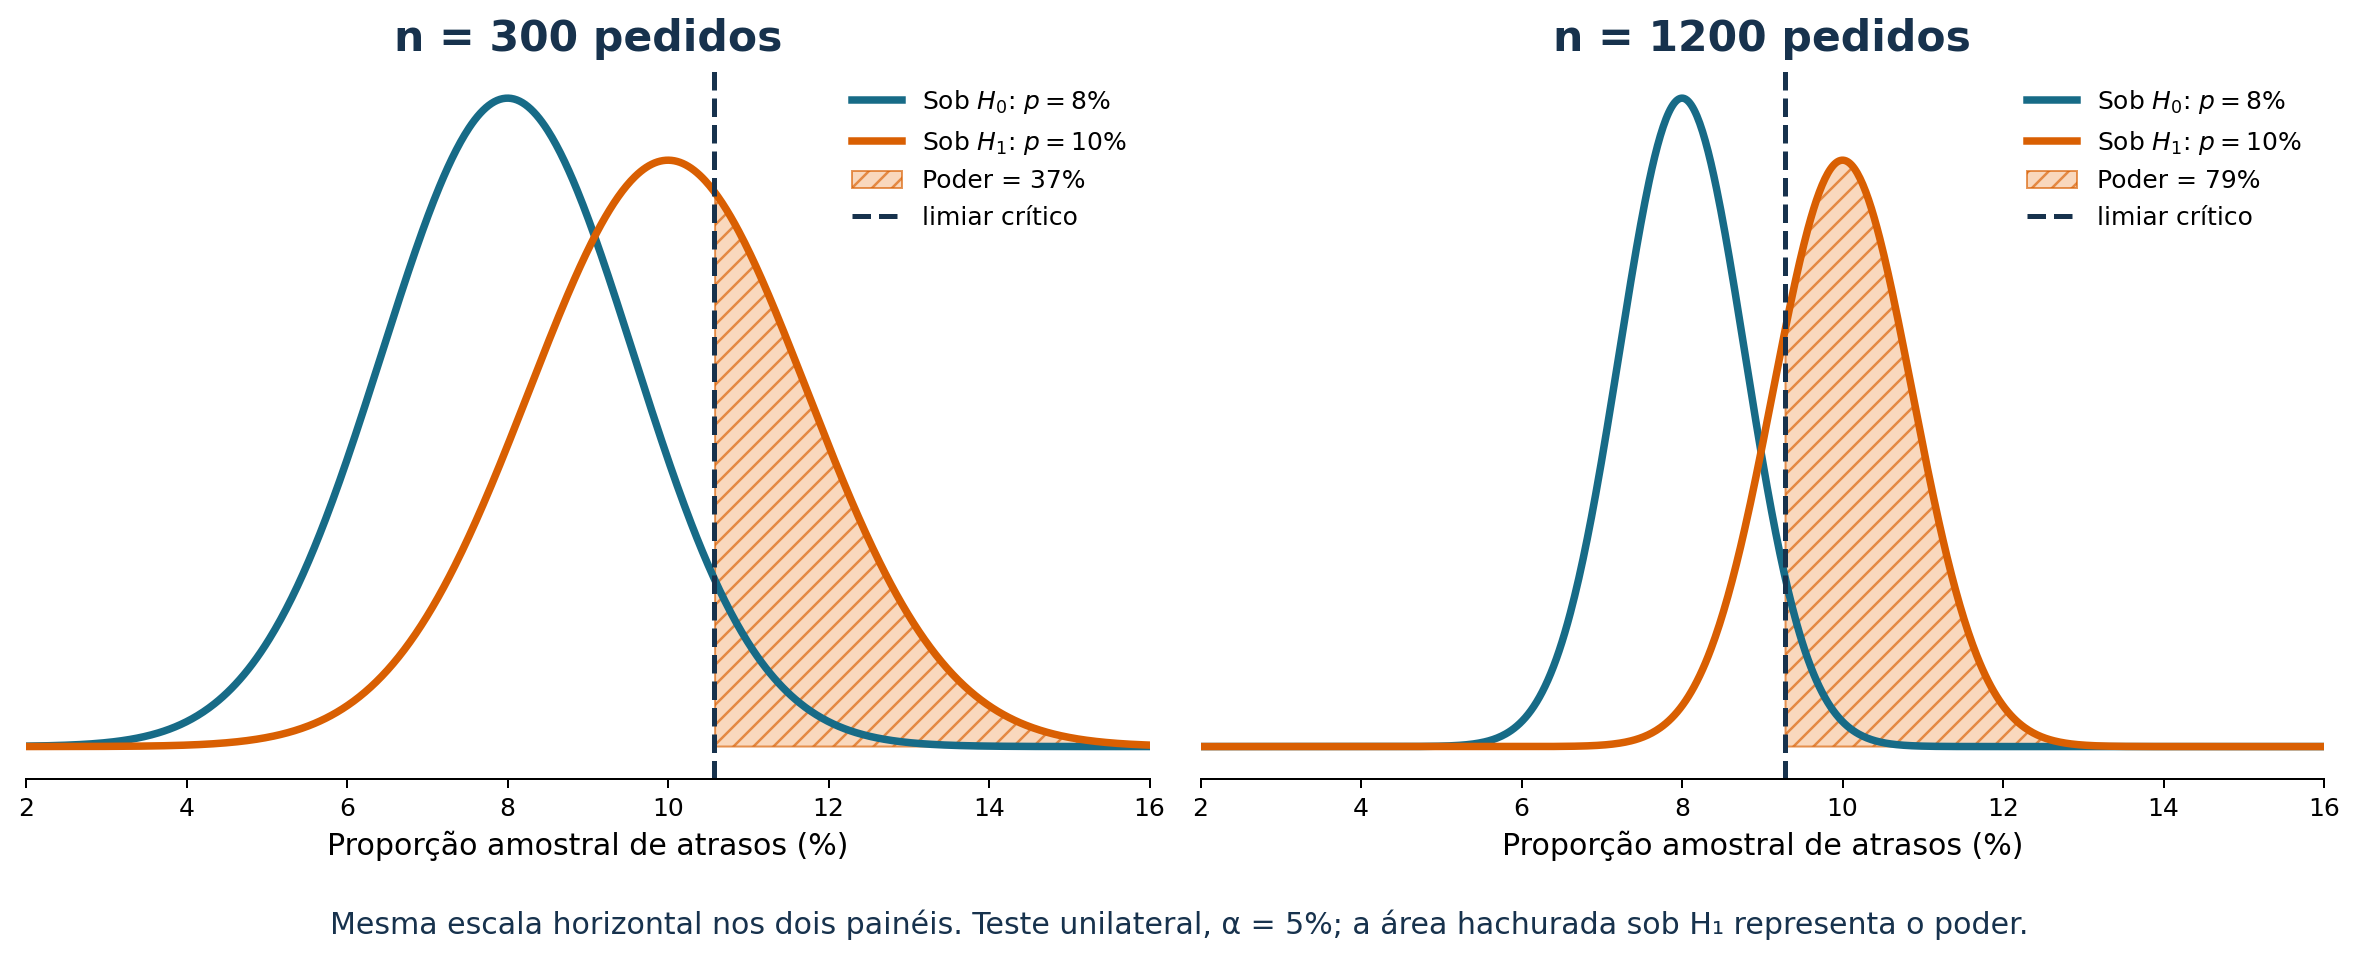

> **Interpretação**
>
> Com 300 pedidos, as distribuições sob 8% e 10% se sobrepõem bastante e
> apenas 37% da distribuição alternativa ultrapassa o limiar. Com 1.200
> pedidos, ambas ficam mais estreitas, a sobreposição diminui e o poder
> sobe para aproximadamente 79%. O efeito verdadeiro não mudou; aumentou
> apenas a capacidade de distingui-lo da flutuação amostral.

# 11. Significância e relevância

Calcule também a diferença $\widehat p-0{,}08$ e traduza-a para atrasos
extras por mil pedidos. Uma decisão operacional deve considerar o
tamanho do efeito, custos e um intervalo de confiança, não apenas o
valor-p.

# 12. Exercícios

1.  Repita o teste com amostras de 300, 1.200 e 5.000 pedidos.
2.  Transforme o teste em bilateral e explique a mudança no valor-p.
3.  Compare o erro tipo I para $\alpha=0{,}01$, 0,05 e 0,10.
4.  Encontre o menor $n$ que atinge 80% de poder quando $p=0{,}10$.
5.  Discuta se os pedidos podem ser tratados como independentes quando
    um mesmo cliente realiza várias compras.

# Fonte e limitações

Base `olistbr/brazilian-ecommerce`, Kaggle. Os dados são históricos e
anonimizados; o limite de 8% é uma referência didática, não uma meta
declarada pela empresa. O notebook não deve ser interpretado como
auditoria operacional da Olist.

# Guia teórico consolidado

## A lógica de um teste

Um teste começa antes dos cálculos: defina estimando, hipótese nula
$H_0$, alternativa $H_A$, estatística e direção. A distribuição nula
descreve valores que a estatística poderia assumir se $H_0$ fosse
verdadeira. O valor-p é a probabilidade, calculada sob $H_0$, de obter
resultado tão ou mais extremo que o observado.

O valor-p não é $P(H_0\mid\text{dados})$, não mede o tamanho do efeito e
não é a probabilidade de o resultado ter ocorrido por acaso.

Formalmente, seja $T=T(X_1,\ldots,X_n)$ uma estatística cuja direção de
extremidade foi definida antes da análise. Em um teste unilateral à
direita,

$$p(X)=P_{H_0}\{T(X^{rep})\geq T(X^{obs})\},$$

em que $X^{obs}$ são os dados observados, $X^{rep}$ representa uma nova
amostra gerada pelo modelo nulo e $P_{H_0}$ indica que a probabilidade é
calculada assumindo $H_0$. No teste bilateral, a região extrema deve
incluir desvios relevantes nas duas direções, frequentemente por meio de
$|T|$ quando a distribuição nula é centrada em zero.

Uma região crítica $\mathcal R_\alpha$ é escolhida para satisfazer
$P_{H_0}(T\in\mathcal R_\alpha)\leq\alpha$. A regra é rejeitar $H_0$
quando $T_{obs}\in\mathcal R_\alpha$, de modo que $\alpha$ limita a
probabilidade de rejeição quando a nula é verdadeira.

## Decisão e erros

O nível $\alpha$ controla a probabilidade de erro tipo I sob as
condições do teste. Erro tipo II é não rejeitar $H_0$ quando uma
alternativa relevante é verdadeira. Poder é $1-\beta$: a chance de
detectar essa alternativa específica.

Para um valor alternativo $\theta_1$,
$\beta(\theta_1)=P_{\theta_1}(T\notin\mathcal R_\alpha)$ e
$\pi(\theta_1)=1-\beta(\theta_1)$ é a função poder. Portanto, poder não
é um único atributo do teste: ele varia com o efeito verdadeiro
$\theta_1$.

Reduzir $\alpha$ diminui falsos positivos, mas pode reduzir poder. Poder
cresce com tamanho do efeito, tamanho amostral, menor variabilidade e,
mantendo o restante, um limiar menos rigoroso.

## Significância e importância

“Rejeitar $H_0$” não significa provar $H_A$; “não rejeitar” não prova
equivalência. Com amostras grandes, efeitos irrelevantes podem ser
significativos. Sempre reporte estimativa, intervalo e consequência
substantiva, além do valor-p.

Testes unilaterais só são defensáveis quando a direção foi escolhida
antes de observar os dados e efeitos na direção oposta não levariam à
mesma ação. Fazer muitos testes aumenta a chance de falsos positivos e
exige definir uma família e uma estratégia de correção.

## Como reduzir falsos positivos quando há muitos testes

Se realizamos vários testes, cresce a probabilidade de encontrar ao menos
um resultado significativo apenas por flutuação amostral. Com 20 testes
independentes, todos sob hipóteses nulas verdadeiras e cada um com
$\alpha=0{,}05$, essa probabilidade é

$$P(\text{ao menos um falso positivo})=1-(1-0{,}05)^{20}\approx 0{,}64.$$

Três estratégias ajudam em momentos diferentes da pesquisa:

- **Pré-registro:** antes de observar os resultados, registrar as
  hipóteses, os desfechos, os critérios de exclusão e o plano de análise.
  Isso distingue análises confirmatórias das explorações feitas depois de
  olhar os dados. Pré-registro não altera matematicamente um valor-p.
- **Correções para múltiplos testes:** ajustar os limiares de rejeição ou
  os valores-p levando em conta a família de testes. Bonferroni e Holm,
  por exemplo, controlam a probabilidade de ao menos um falso positivo na
  família. A Aula 15 detalha esses procedimentos.
- **Validação externa:** verificar a conclusão em uma amostra, período,
  instituição ou população independente daquela usada para descobrir o
  resultado. Isso avalia se o achado se repete fora da amostra original.

> **Interpretação**
>
> Essas medidas não são sinônimas. A correção atua na regra estatística da
> família de testes; o pré-registro melhora a transparência do processo; e
> a validação externa procura evidência independente. As três podem ser
> usadas em conjunto.

# Questões de revisão da Aula 11

1.  O que um valor-p de 0,02 afirma — e o que ele não afirma?
2.  Por que aumentar $n$ eleva o poder quando $p_0$, $p_1$ e $\alpha$
    permanecem fixos?

Respostas comentadas

1.  Sob $H_0$, resultados tão ou mais extremos ocorreriam com
    probabilidade 2%. Isso não significa que
    $P(H_0\mid\text{dados})=0{,}02$ nem mede relevância prática.
2.  O erro padrão diminui, as distribuições sob $H_0$ e $H_1$ ficam mais
    estreitas e sua sobreposição diminui.